## Questao 1 - Cadeia de Markov absorvente

Nesta questao, o sensor IoT e modelado por uma cadeia de Markov com cinco estados. O estado 4 representa falha total e e absorvente.

### Definicao da matriz de transicao

In [3]:
import numpy as np
import matplotlib.pyplot as plt

estados = [
    '0 - operacional',
    '1 - pequena degradacao',
    '2 - falha moderada',
    '3 - modo critico',
    '4 - queimado'
]

P = np.array([
    [0.7, 0.3, 0.0, 0.0, 0.0],
    [0.2, 0.5, 0.3, 0.0, 0.0],
    [0.0, 0.1, 0.5, 0.4, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.4],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

print('Matriz de transicao P:')
print(P)
print('Soma das linhas:', P.sum(axis=1))

Matriz de transicao P:
[[0.7 0.3 0.  0.  0. ]
 [0.2 0.5 0.3 0.  0. ]
 [0.  0.1 0.5 0.4 0. ]
 [0.  0.  0.  0.6 0.4]
 [0.  0.  0.  0.  1. ]]
Soma das linhas: [1. 1. 1. 1. 1.]


### a) Diagrama de transicao de estados

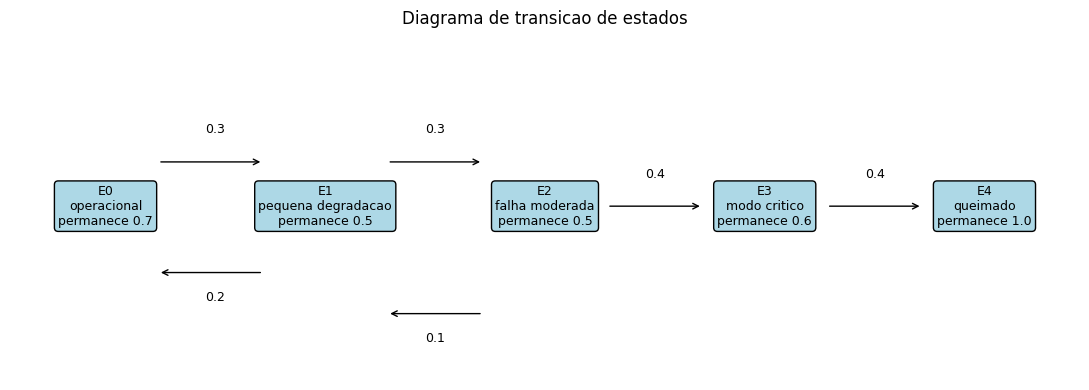

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis('off')

posicoes = {
    'E0': (0, 1.5, 'E0\noperacional\npermanece 0.7'),
    'E1': (2.3, 1.5, 'E1\npequena degradacao\npermanece 0.5'),
    'E2': (4.6, 1.5, 'E2\nfalha moderada\npermanece 0.5'),
    'E3': (6.9, 1.5, 'E3\nmodo critico\npermanece 0.6'),
    'E4': (9.2, 1.5, 'E4\nqueimado\npermanece 1.0')
}

for estado, (x, y, texto) in posicoes.items():
    ax.text(x, y, texto, ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='black'))

def seta(x1, y1, x2, y2, probabilidade, xt, yt):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->'))
    ax.text(xt, yt, probabilidade, ha='center', fontsize=9)

seta(0.55, 1.78, 1.65, 1.78, '0.3', 1.15, 1.96)
seta(1.65, 1.08, 0.55, 1.08, '0.2', 1.15, 0.90)
seta(2.95, 1.78, 3.95, 1.78, '0.3', 3.45, 1.96)
seta(3.95, 0.82, 2.95, 0.82, '0.1', 3.45, 0.64)
seta(5.25, 1.5, 6.25, 1.5, '0.4', 5.75, 1.68)
seta(7.55, 1.5, 8.55, 1.5, '0.4', 8.05, 1.68)

ax.set_xlim(-1, 10.2)
ax.set_ylim(0.4, 2.6)
ax.set_title('Diagrama de transicao de estados')
plt.tight_layout()
plt.show()

### c) Probabilidade de falha total exatamente no 4o ciclo

In [5]:
P4 = np.linalg.matrix_power(P, 4)
prob_falha_4 = P4[0, 4]

print('P^4:')
print(P4)
print('Probabilidade:', prob_falha_4)
print('Porcentagem:', prob_falha_4 * 100, '%')

P^4:
[[0.3907 0.3294 0.1827 0.0828 0.0144]
 [0.2196 0.232  0.2076 0.216  0.1248]
 [0.0406 0.0692 0.1102 0.2936 0.4864]
 [0.     0.     0.     0.1296 0.8704]
 [0.     0.     0.     0.     1.    ]]
Probabilidade: 0.014400000000000003
Porcentagem: 1.4400000000000004 %


### d) Matriz fundamental

In [6]:
Q = P[:4, :4]
R = P[:4, 4:5]
I = np.eye(4)
N = np.linalg.inv(I - Q)

print('Q:')
print(Q)
print('Matriz fundamental N:')
print(N)

Q:
[[0.7 0.3 0.  0. ]
 [0.2 0.5 0.3 0. ]
 [0.  0.1 0.5 0.4]
 [0.  0.  0.  0.6]]
Matriz fundamental N:
[[6.11111111 4.16666667 2.5        2.5       ]
 [2.77777778 4.16666667 2.5        2.5       ]
 [0.55555556 0.83333333 2.5        2.5       ]
 [0.         0.         0.         2.5       ]]


### e) Numero medio de ciclos ate a absorcao

In [7]:
tempos_medios = N @ np.ones(4)

for estado, tempo in enumerate(tempos_medios):
    print(f'Estado {estado}: {tempo:.4f} ciclos')

Estado 0: 15.2778 ciclos
Estado 1: 11.9444 ciclos
Estado 2: 6.3889 ciclos
Estado 3: 2.5000 ciclos


### f) Probabilidade de absorcao no estado 4

In [8]:
B = N @ R

for estado, prob in enumerate(B.flatten()):
    print(f'Estado inicial {estado}: {prob:.4f}')

Estado inicial 0: 1.0000
Estado inicial 1: 1.0000
Estado inicial 2: 1.0000
Estado inicial 3: 1.0000


### g) Simulacao da cadeia e evolucao temporal

Caminho simulado: [0, 1, 1, 2, 2, 2, 2, 3, 4]
Ciclos ate absorcao: 8


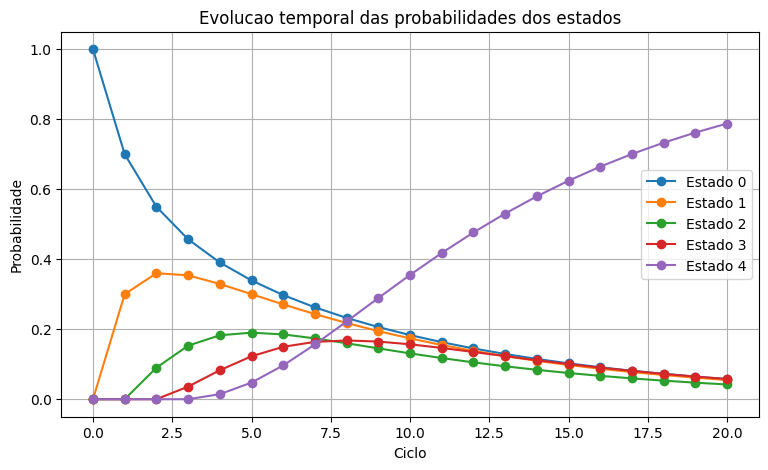

In [9]:
def simular_cadeia(P, estado_inicial=0, max_ciclos=100, seed=10):
    rng = np.random.default_rng(seed)
    estado = estado_inicial
    caminho = [estado]

    for i in range(max_ciclos):
        estado = rng.choice(len(P), p=P[estado])
        caminho.append(estado)

        if estado == 4:
            break

    return caminho

caminho = simular_cadeia(P)
print('Caminho simulado:', caminho)
print('Ciclos ate absorcao:', len(caminho) - 1)

distribuicao = np.array([1, 0, 0, 0, 0], dtype=float)
historico = [distribuicao.copy()]

for i in range(20):
    distribuicao = distribuicao @ P
    historico.append(distribuicao.copy())

historico = np.array(historico)

plt.figure(figsize=(9, 5))
for estado in range(5):
    plt.plot(historico[:, estado], marker='o', label=f'Estado {estado}')

plt.xlabel('Ciclo')
plt.ylabel('Probabilidade')
plt.title('Evolucao temporal das probabilidades dos estados')
plt.grid(True)
plt.legend()
plt.show()